first data set happiness-index-2018-2019

In [102]:
import kagglehub
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns





path = kagglehub.dataset_download("sougatapramanick/happiness-index-2018-2019")
print("Path to dataset files:", path)
csv_files = list(Path(path).rglob("*.csv"))
if csv_files:
    df = pd.read_csv(csv_files[0])
    print("\n First few rows of the dataset:")
    print(df.head())
else:
    print("No CSV files found")
    




print(f'\n Number of duplicates: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Number of duplicates after cleaning: {df.duplicated().sum()}')

print("\n Missing Values:\n", df.isnull().sum())


df.columns = df.columns.str.strip()
print("\n Dataset Information:")
df.info()

happiest_country = df.loc[df['Score'].idxmax()]
print("\n Happiest country details:")
print(happiest_country)

unhappiest_country = df.loc[df['Score'].idxmin()]
print("\n Unhappiest country details:")
print(unhappiest_country)





print(" Top 5 Happiest Countries:\n------------------------")

top_5_happy = df.nlargest(5, 'Score')[['Country or region', 'Score', 'GDP per capita']]
print(str(top_5_happy))

print("\n Top 5 Unhappiest Countries:\n------------------------")
top_5_unhappy = df.nsmallest(5, 'Score')[['Country or region', 'Score', 'GDP per capita']]
print(str(top_5_unhappy))

print("\n Summary Stats:\n", df.describe())

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\sougatapramanick\happiness-index-2018-2019\versions\1

 First few rows of the dataset:
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.632           1.305           1.592   
1             2            Norway  7.594           1.456           1.582   
2             3           Denmark  7.555           1.351           1.590   
3             4           Iceland  7.495           1.343           1.644   
4             5       Switzerland  7.487           1.420           1.549   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.874                         0.681       0.202   
1                    0.861                         0.686       0.286   
2                    0.868                         0.683       0.284   
3                    0.914                         0.677       0.353   
4                    0.927       

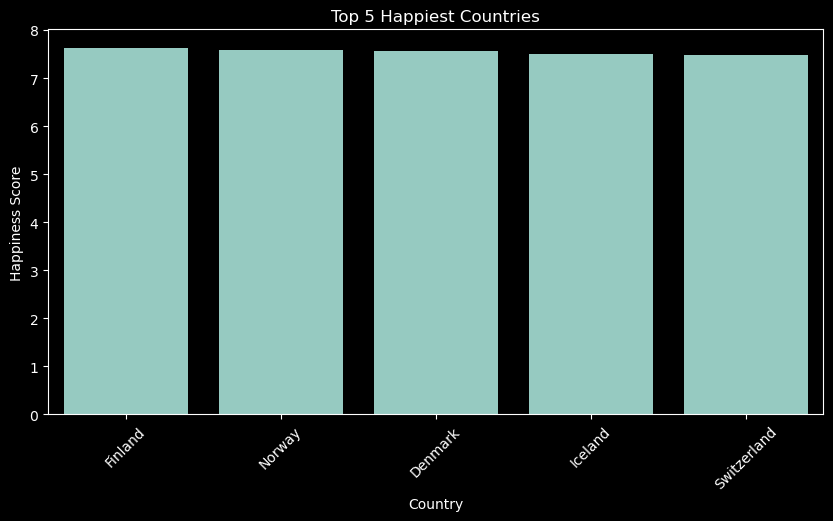

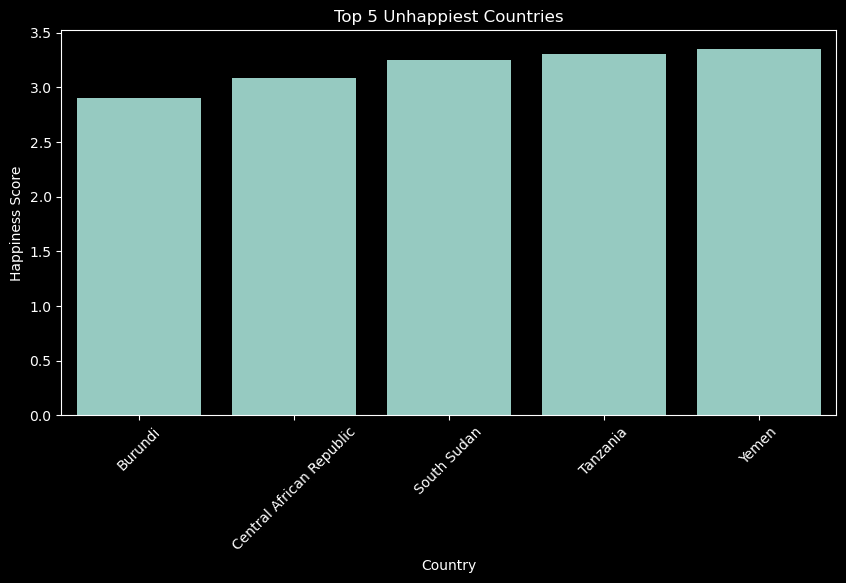

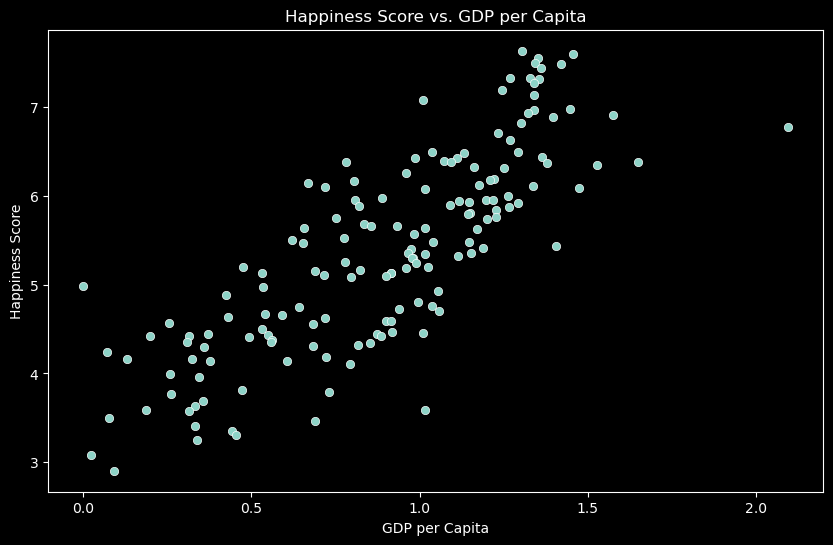

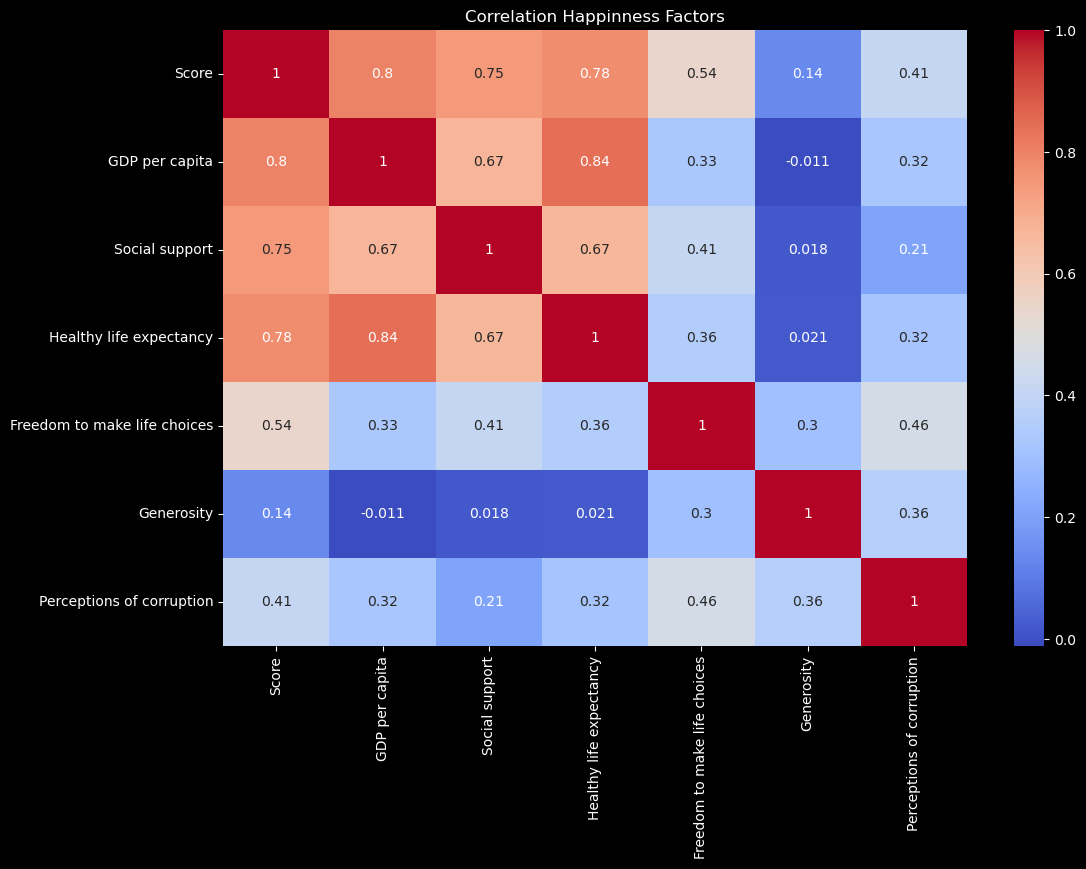

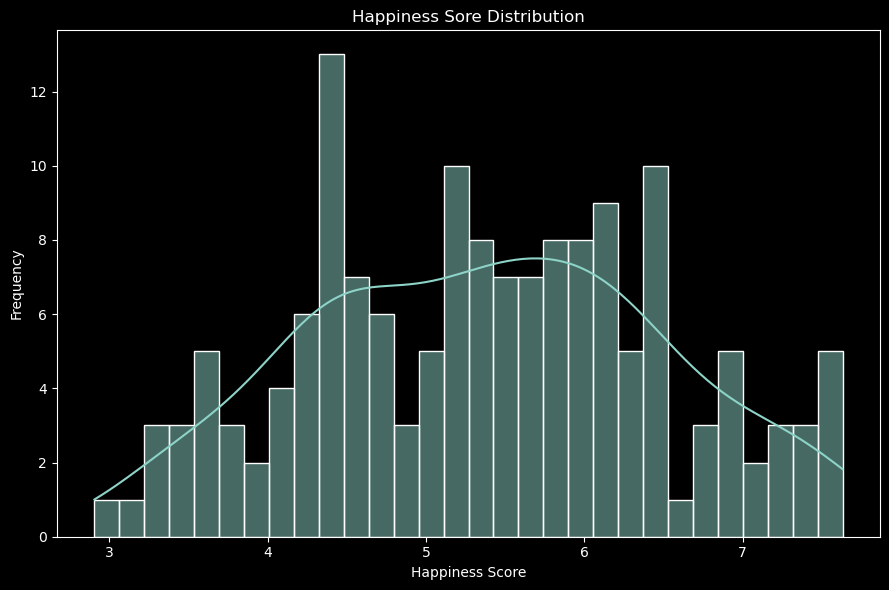

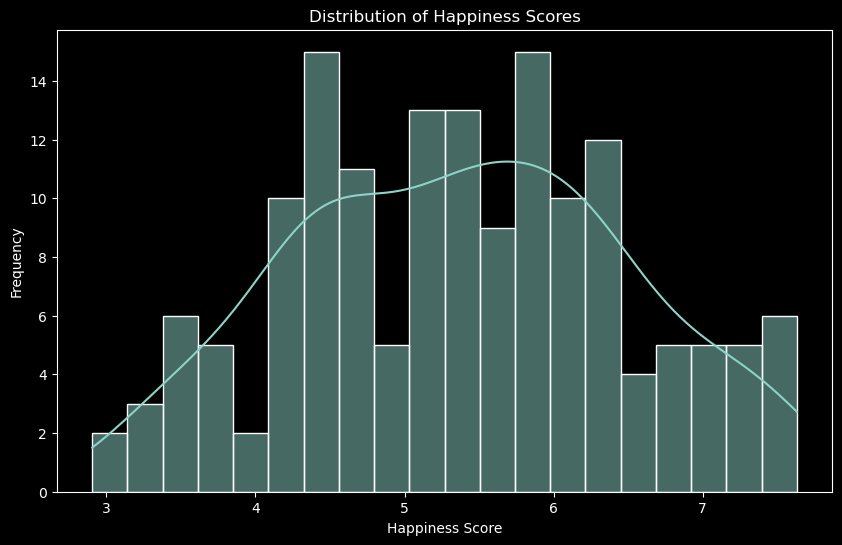

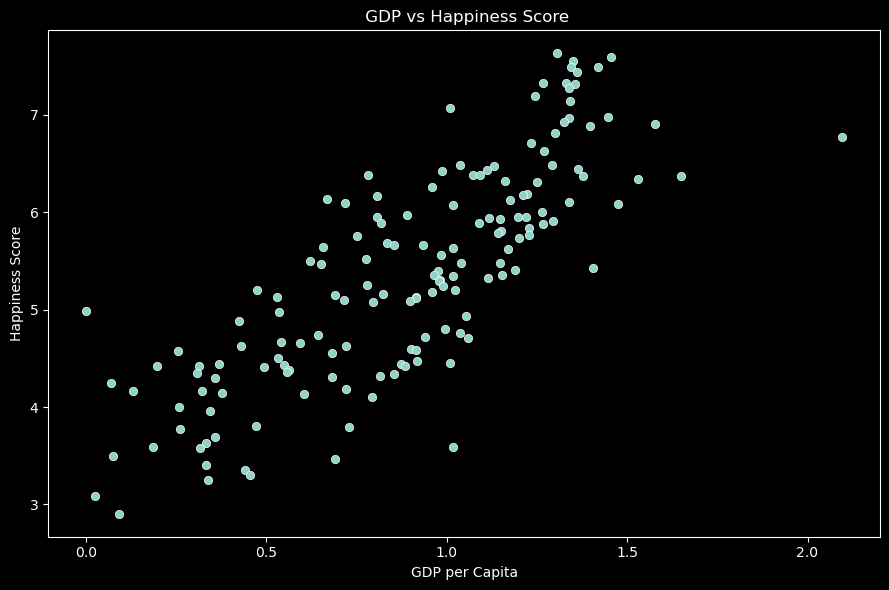

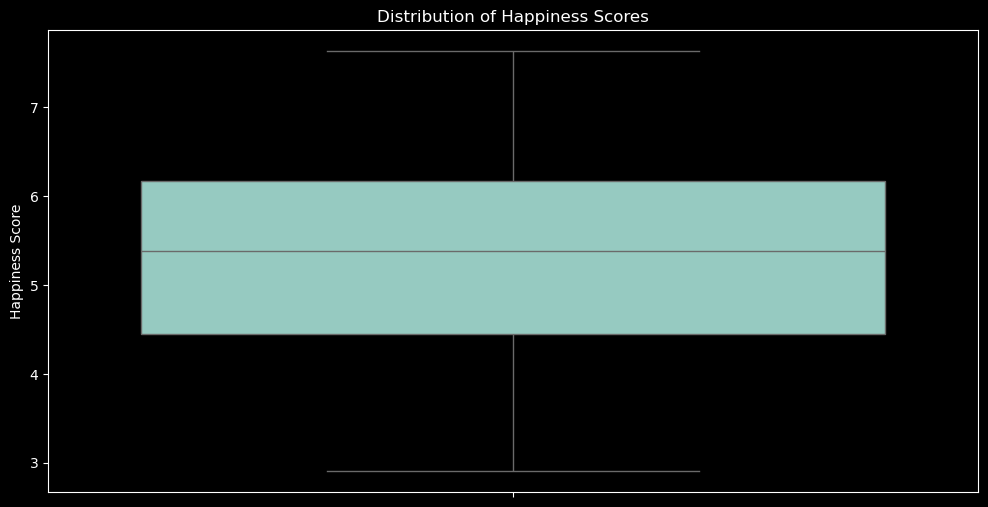

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


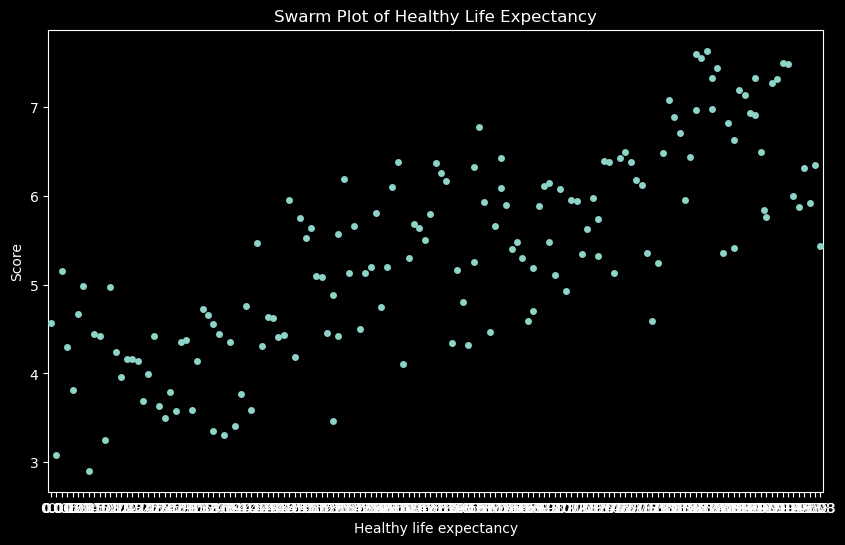

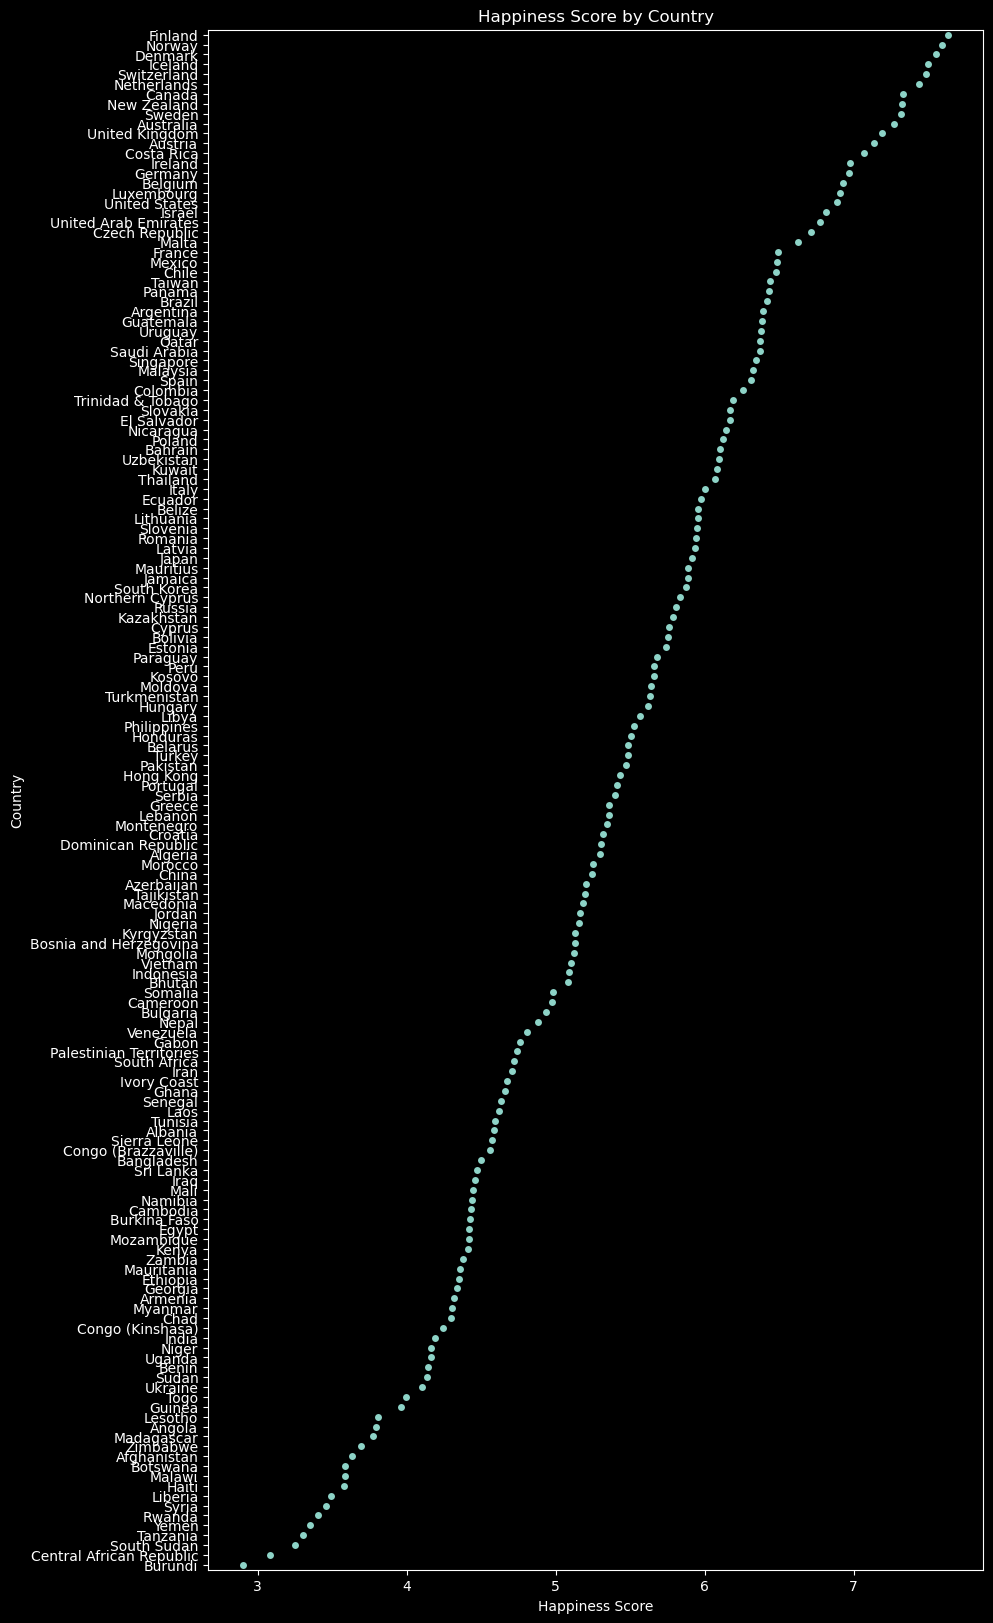

In [109]:
#Data Viwsualization

plt.figure(figsize=(10, 5))
sns.barplot(x='Country or region', y='Score', data=top_5_happy)
plt.title('Top 5 Happiest Countries')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='Country or region', y='Score', data=top_5_unhappy)
plt.title('Top 5 Unhappiest Countries')
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDP per capita', y='Score', data=df)
plt.title('Happiness Score vs. GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df[['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Happinness Factors')
plt.show()

plt.figure(figsize=(9, 6))
sns.histplot(data=df, x="Score", kde=True, bins=30)
plt.title("Happiness Sore Distribution")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
sns.histplot(df['Score'], kde=True, bins=20)
plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="GDP per capita", y="Score")
plt.title(" GDP vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(y='Score', data=df)
plt.title('Distribution of Happiness Scores')
plt.ylabel('Happiness Score')
plt.show()



plt.figure(figsize=(10, 6))
sns.swarmplot(x='Healthy life expectancy',y='Score', data=df)
plt.title('Swarm Plot of Healthy Life Expectancy')
plt.xlabel('Healthy life expectancy')
plt.show()








plt.figure(figsize=(10, 20))
sns.stripplot(y='Country or region', x='Score', data=df)
plt.title('Happiness Score by Country')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.show()

In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
X_hap = df[['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]
y_hap = df['Score']
X = X_hap
y = y_hap
X = X_hap
y = y_hap
X_hap_train, X_hap_test, y_hap_train, y_hap_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Linear Regression
lr = LinearRegression()
lr.fit(X_hap_train, y_hap_train)
y_pred_lr = lr.predict(X_hap_test)
print("Using Linear Regression, we predicted the happiness scores for the test countries. The Root Mean Squared Error (RMSE) tells us how far off our predictions are on average, and the R2 score shows how well our model explains the actual scores.")
print("Linear Regression RMSE:", mean_squared_error(y_hap_test, y_pred_lr)**0.5)
print("Linear Regression R2:", r2_score(y_hap_test, y_pred_lr))
# Random Forest Regression
rf = RandomForestRegressor(random_state=42)
rf.fit(X_hap_train, y_hap_train)
y_pred_rf = rf.predict(X_hap_test)
print("\nUsing Random Forest Regression, we also predicted happiness scores. RMSE and R2 help us measure how accurate and reliable these predictions are.")
print("Random Forest RMSE:", mean_squared_error(y_hap_test, y_pred_rf)**0.5)
print("Random Forest R2:", r2_score(y_hap_test, y_pred_rf))
# Ridge Regression
ridge = Ridge()
ridge.fit(X_hap_train, y_hap_train)
y_pred_ridge = ridge.predict(X_hap_test)
print("\nWith Ridge Regression, we made similar predictions. Again, RMSE shows the average error, and R2 shows how well the model fits the data.")
print("Ridge Regression RMSE:", mean_squared_error(y_hap_test, y_pred_ridge)**0.5)
print("Ridge Regression R2:", r2_score(y_hap_test, y_pred_ridge))


Using Linear Regression, we predicted the happiness scores for the test countries. The Root Mean Squared Error (RMSE) tells us how far off our predictions are on average, and the R2 score shows how well our model explains the actual scores.
Linear Regression RMSE: 0.5630048363352881
Linear Regression R2: 0.6939247547569339

Using Random Forest Regression, we also predicted happiness scores. RMSE and R2 help us measure how accurate and reliable these predictions are.
Random Forest RMSE: 0.5904120632924519
Random Forest R2: 0.6633997766225339

With Ridge Regression, we made similar predictions. Again, RMSE shows the average error, and R2 shows how well the model fits the data.
Ridge Regression RMSE: 0.5583502775698522
Ridge Regression R2: 0.6989646979433068


In [ ]:
pip install kagglehub

second data set 

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\himanshupoddar\zomato-bangalore-restaurants\versions\1

 First few rows of the dataset:
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  vot

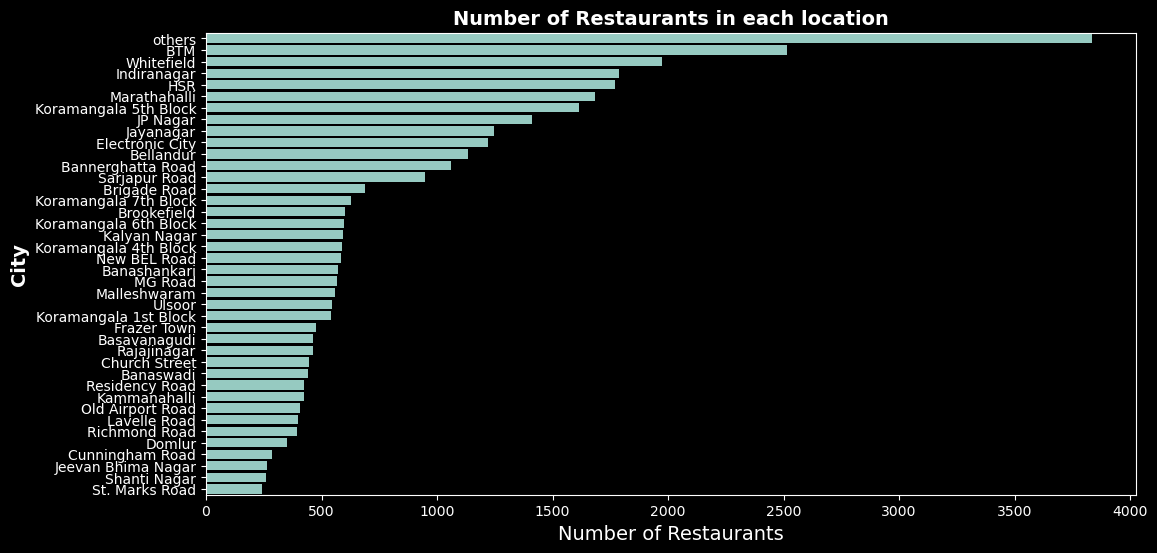

NameError: name 'plot_data' is not defined

<Figure size 1800x1200 with 0 Axes>